Generating Q1 vs Q4 comparison histogram...

=== Bar Data for Q1 vs Q4 ===
Time Period | Price Difference Value
----------------------------------------
   2017-02 |          -0.296088
   2017-03 |          -0.293402
   2017-04 |          -0.293620
   2017-05 |          -0.294219
   2017-06 |          -0.294128
   2017-07 |          -0.294095
   2017-08 |          -0.293402
   2017-09 |          -0.293001
   2017-10 |          -0.292232
   2017-11 |          -0.291620
   2017-12 |          -0.290566
   2018-01 |          -0.290111
   2018-02 |          -0.289954
   2018-03 |          -0.289121
   2018-04 |          -0.288195
   2018-05 |          -0.287200
   2018-06 |          -0.286198
   2018-07 |          -0.287279
   2018-08 |          -0.286592
   2018-09 |          -0.286059
   2018-10 |          -0.285961
   2018-11 |          -0.285715
   2018-12 |          -0.286020
   2019-01 |          -0.285158
   2019-02 |          -0.283033
   2019-03 |          -0.280737
   2019-04 |   

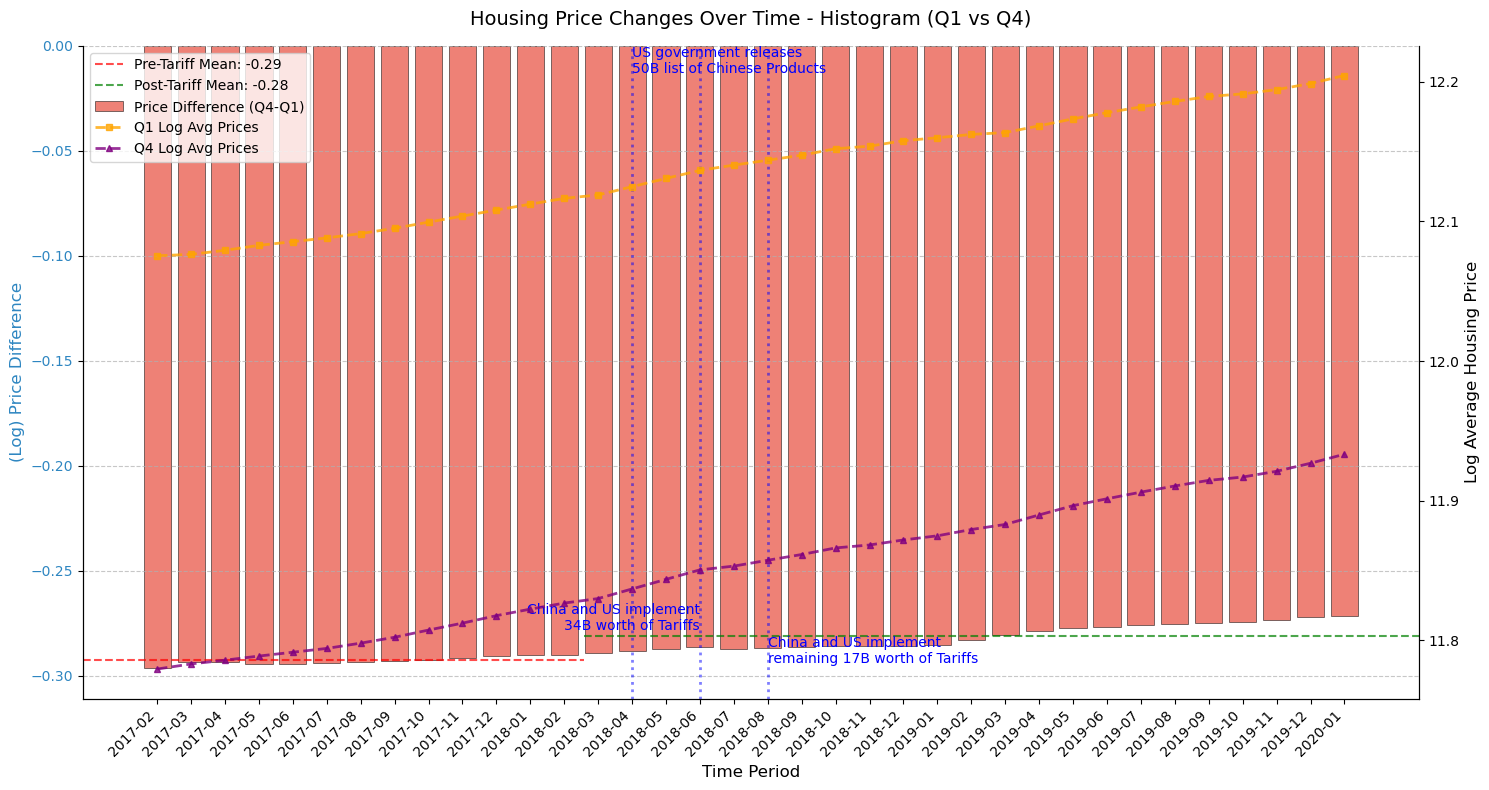

Plot saved as: images/housing_price_changes_histogram_q1_q4.png

Generating Q2 vs Q3 comparison histogram...

=== Bar Data for Q2 vs Q3 ===
Time Period | Price Difference Value
----------------------------------------
   2017-02 |          -0.111502
   2017-03 |          -0.111614
   2017-04 |          -0.112105
   2017-05 |          -0.112320
   2017-06 |          -0.112327
   2017-07 |          -0.112313
   2017-08 |          -0.112192
   2017-09 |          -0.112206
   2017-10 |          -0.112196
   2017-11 |          -0.112203
   2017-12 |          -0.112104
   2018-01 |          -0.112061
   2018-02 |          -0.111933
   2018-03 |          -0.112374
   2018-04 |          -0.111376
   2018-05 |          -0.110439
   2018-06 |          -0.109755
   2018-07 |          -0.109684
   2018-08 |          -0.109660
   2018-09 |          -0.109761
   2018-10 |          -0.109707
   2018-11 |          -0.109819
   2018-12 |          -0.109787
   2019-01 |          -0.109832
   2019-02 |  

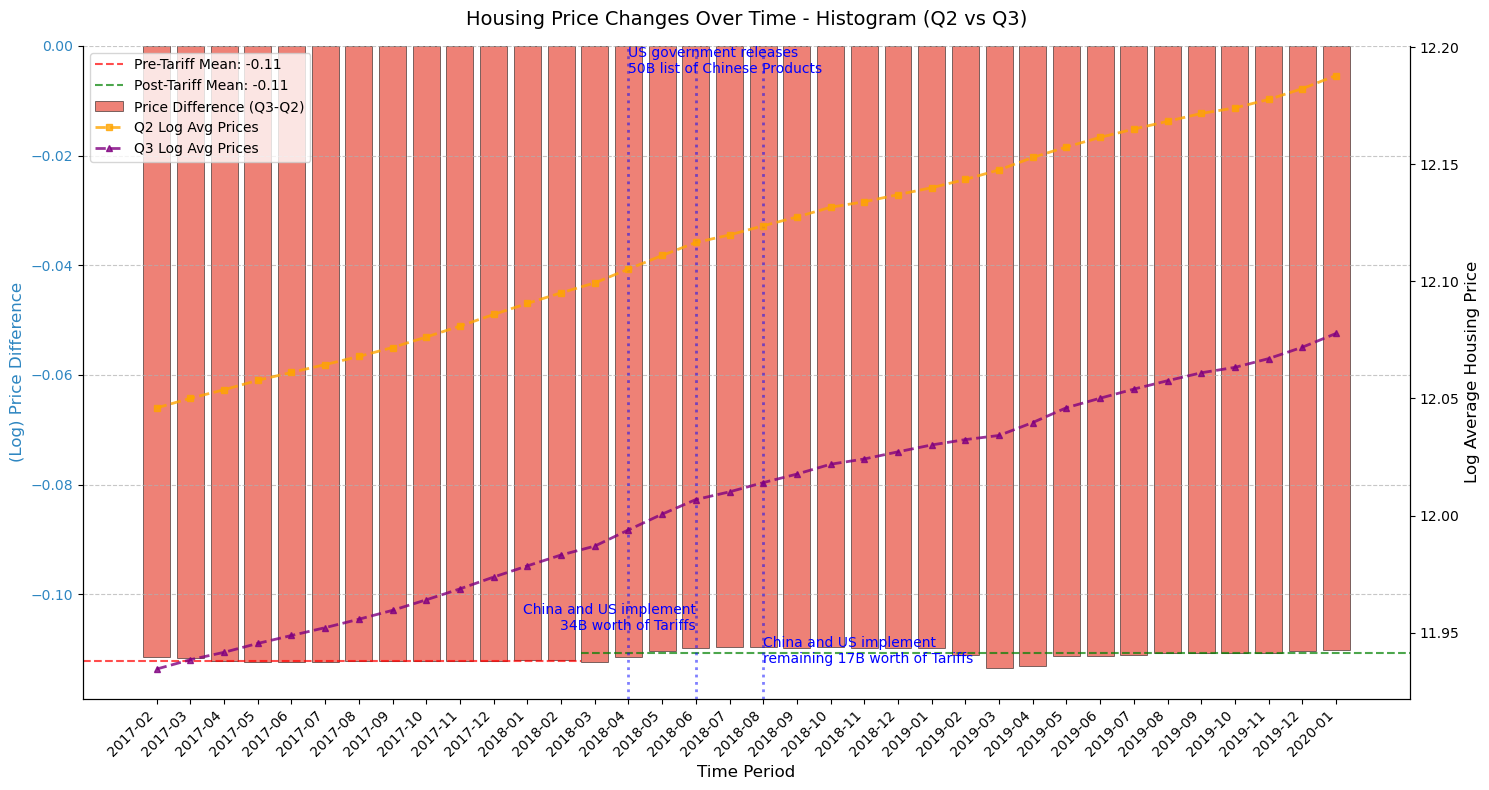

Plot saved as: images/housing_price_changes_histogram_q2_q3.png

Generating Q1 vs Q2 comparison histogram...

=== Bar Data for Q1 vs Q2 ===
Time Period | Price Difference Value
----------------------------------------
   2017-02 |          -0.029461
   2017-03 |          -0.026330
   2017-04 |          -0.025597
   2017-05 |          -0.025139
   2017-06 |          -0.024401
   2017-07 |          -0.023764
   2017-08 |          -0.023376
   2017-09 |          -0.023372
   2017-10 |          -0.023291
   2017-11 |          -0.022964
   2017-12 |          -0.022307
   2018-01 |          -0.021812
   2018-02 |          -0.021459
   2018-03 |          -0.019645
   2018-04 |          -0.019692
   2018-05 |          -0.019767
   2018-06 |          -0.020024
   2018-07 |          -0.020560
   2018-08 |          -0.020158
   2018-09 |          -0.019994
   2018-10 |          -0.020455
   2018-11 |          -0.019955
   2018-12 |          -0.020842
   2019-01 |          -0.019975
   2019-02 |  

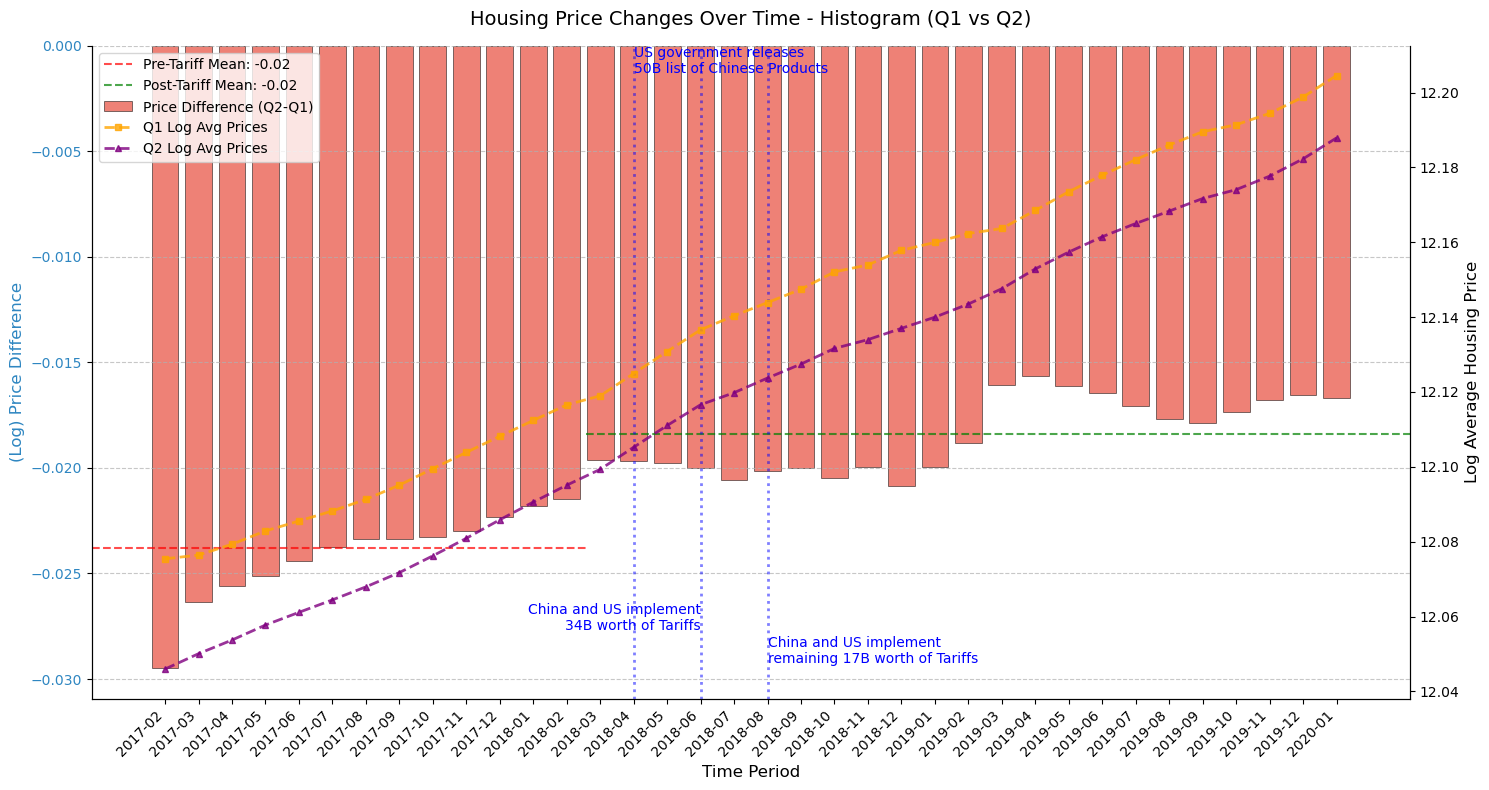

Plot saved as: images/housing_price_changes_histogram_q1_q2.png

Generating Q1 vs Q3 comparison histogram...

=== Bar Data for Q1 vs Q3 ===
Time Period | Price Difference Value
----------------------------------------
   2017-02 |          -0.140962
   2017-03 |          -0.137944
   2017-04 |          -0.137702
   2017-05 |          -0.137459
   2017-06 |          -0.136728
   2017-07 |          -0.136076
   2017-08 |          -0.135568
   2017-09 |          -0.135578
   2017-10 |          -0.135487
   2017-11 |          -0.135167
   2017-12 |          -0.134411
   2018-01 |          -0.133873
   2018-02 |          -0.133391
   2018-03 |          -0.132018
   2018-04 |          -0.131069
   2018-05 |          -0.130207
   2018-06 |          -0.129779
   2018-07 |          -0.130244
   2018-08 |          -0.129817
   2018-09 |          -0.129755
   2018-10 |          -0.130163
   2018-11 |          -0.129774
   2018-12 |          -0.130629
   2019-01 |          -0.129807
   2019-02 |  

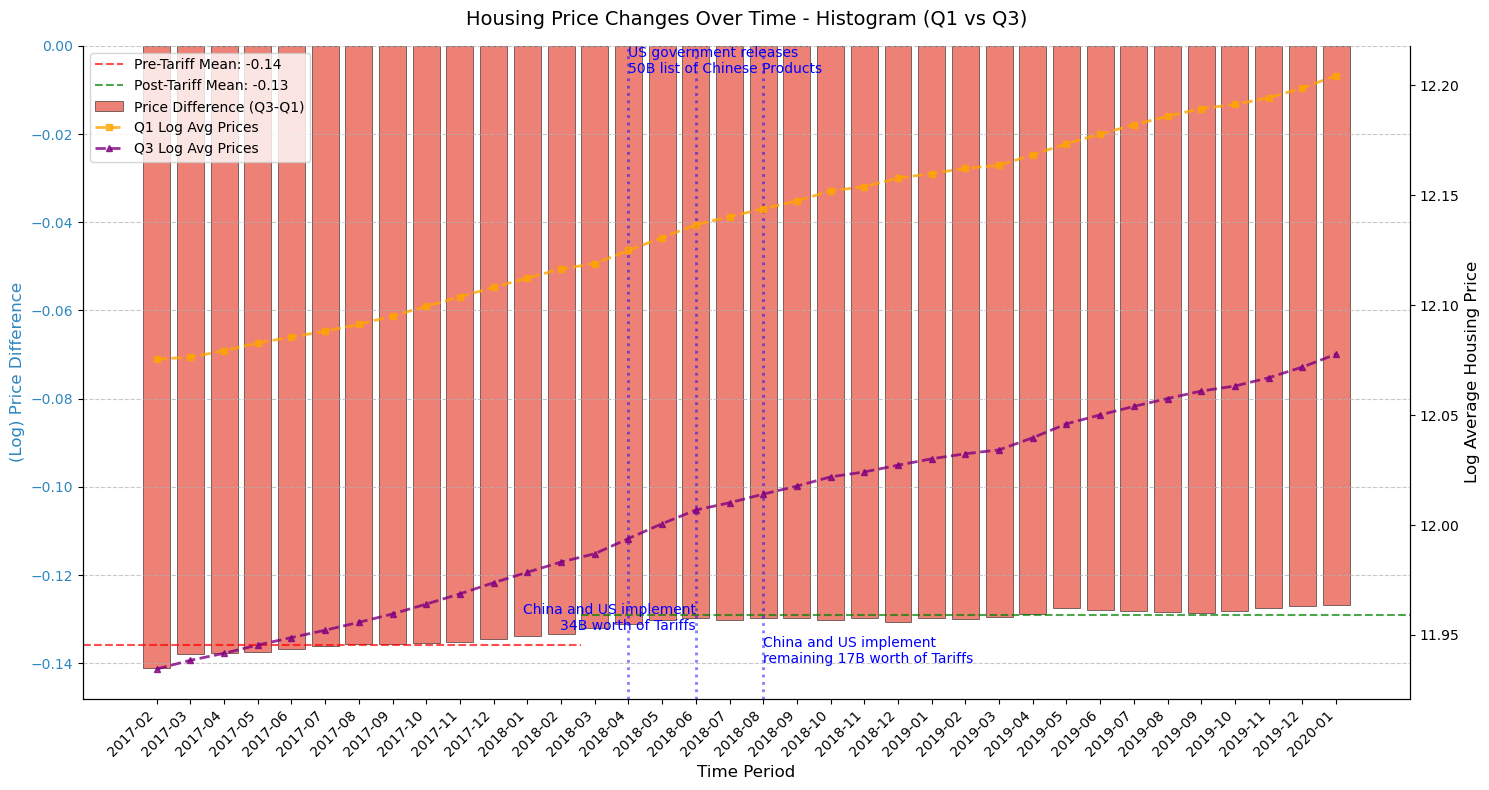

Plot saved as: images/housing_price_changes_histogram_q1_q3.png

All histogram plots generated successfully!


In [24]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# Read Zillow data
zillow = pd.read_csv('Data/zillow county.csv')

# Select and convert datetime columns
column_names_to_convert = zillow.columns[9:]
new_column_names = pd.to_datetime(column_names_to_convert)
zillow.columns = list(zillow.columns[:9]) + list(new_column_names)

# Drop columns outside the desired year range (2017-2019)
for column in new_column_names:
    column_year = column.year
    if not (2017 <= column_year <= 2019):
        zillow = zillow.drop(columns=[column])

# Make county FIPS column
zillow['CountyFIPS'] = (
    zillow['StateCodeFIPS'].astype(str).str.zfill(2) + 
    zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)
)

# Read tariff data
tariffs = pd.read_csv('Data/ustariffs-by-county.csv')

# Clean tariff data
tariffs_clean = tariffs.drop(columns=['Unnamed: 0','emplvl_2017', 'fips', 'total_employment', 'int_area_fips',
       '2017_income', '2017_population', 'total_imp_pc', 'china_imp_pc'])

# Filter for years and clean area_fips
tariffs_clean['time'] = pd.to_datetime(tariffs_clean['time'])
tariffs_clean = tariffs_clean[(tariffs_clean['time'].dt.year >= 2017) & (tariffs_clean['time'].dt.year <= 2019)]
tariffs_clean['area_fips'] = tariffs_clean['area_fips'].astype(str).str.zfill(5)
tariffs_clean = tariffs_clean[~tariffs_clean['area_fips'].astype(str).str.endswith('999')]
tariffs_clean = tariffs_clean[tariffs_clean['time'] != '2017-01-01 00:00:00']
if 'state' in tariffs_clean.columns:
    tariffs_clean = tariffs_clean.drop('state', axis=1)
tariffs_clean = tariffs_clean.reset_index(drop=True)

# Pivot tariff data and calculate change
tariffs_clean_pivoted = tariffs_clean.pivot(index='area_fips', columns='time', values='tariff')
tariffs_clean_pivoted = tariffs_clean_pivoted.reset_index()
tariffs_clean_pivoted['change'] = tariffs_clean_pivoted.iloc[:,-1] - tariffs_clean_pivoted.iloc[:,1]
tariffs_clean_pivoted = tariffs_clean_pivoted.sort_values(by=['change'], ascending=False)
tariffs_clean_pivoted = tariffs_clean_pivoted.reset_index(drop=True)
tariffs_clean_pivoted = tariffs_clean_pivoted.dropna()

# Create quartiles based on tariff changes
tariffs_clean_pivoted['quartile'] = pd.qcut(tariffs_clean_pivoted['change'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Get all quartiles
q1 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q1']
q2 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q2']
q3 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q3']
q4 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q4']

# Clean data columns to drop
drop_columns = ['Metro','StateCodeFIPS','MunicipalCodeFIPS','State','StateName','RegionType','RegionName','SizeRank','RegionID','CountyFIPS']

# Function to create quartile comparison histogram plot
def create_quartile_histogram_plot(q_high, q_low, q_high_name, q_low_name, title_suffix, filename):
    # Filter Zillow data for the quartiles
    zillow_high_tariffs = zillow[zillow['CountyFIPS'].isin(q_high['area_fips'])]
    zillow_low_tariffs = zillow[zillow['CountyFIPS'].isin(q_low['area_fips'])]
    
    # Clean data and calculate means
    zillow_high_clean = zillow_high_tariffs.drop(columns=drop_columns)
    zillow_low_clean = zillow_low_tariffs.drop(columns=drop_columns)
    
    # Calculate log means for both difference and individual quartiles
    zillow_high_log_mean = pd.DataFrame([np.log(zillow_high_clean.mean())])
    zillow_low_log_mean = pd.DataFrame([np.log(zillow_low_clean.mean())])
    diff = zillow_high_log_mean - zillow_low_log_mean
    
    # Calculate averages before and after the split date
    split_date = pd.Timestamp('2018-02-28')
    before_mask = diff.columns <= split_date
    after_mask = diff.columns > split_date
    before_mean = diff.iloc[0, before_mask].mean()
    after_mean = diff.iloc[0, after_mask].mean()
    
    # Create the plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    # Convert dates to month format and shift them forward by one month for x-axis
    x_dates = [(d + pd.DateOffset(months=1)).strftime('%Y-%m') for d in diff.columns]
    
    # Create histogram bars for price difference on left y-axis
    bar_width = 0.8
    x_positions = range(len(x_dates))
    diff_values = diff.iloc[0].values
    
    # Display the data being used for the bars
    print(f"\n=== Bar Data for {title_suffix} ===")
    print("Time Period | Price Difference Value")
    print("-" * 40)
    for i, (date, value) in enumerate(zip(x_dates, diff_values)):
        print(f"{date:>10} | {value:>18.6f}")
    
    print(f"\nSummary Statistics:")
    print(f"Min value: {diff_values.min():.6f}")
    print(f"Max value: {diff_values.max():.6f}")
    print(f"Mean value: {diff_values.mean():.6f}")
    print(f"Std deviation: {diff_values.std():.6f}")
    print(f"Number of bars: {len(diff_values)}")
    print("=" * 50)
    
    # Color bars based on whether they're above or below zero
    colors = ['#2E86C1' if val >= 0 else '#E74C3C' for val in diff_values]
    
    bars = ax1.bar(x_positions, diff_values, 
                   width=bar_width, 
                   color=colors,
                   alpha=0.7,
                   edgecolor='black',
                   linewidth=0.5,
                   label=f'Price Difference ({q_high_name}-{q_low_name})')
    
    # Create second y-axis for log average housing prices
    ax2 = ax1.twinx()
    
    # Plot log mean prices for both quartiles on right y-axis
    ax2.plot(x_positions, zillow_low_log_mean.iloc[0].values, 
             marker='s', 
             linewidth=2, 
             markersize=5,
             color='orange',
             linestyle='--',
             alpha=0.8,
             label=f'{q_low_name} Log Avg Prices')
    
    ax2.plot(x_positions, zillow_high_log_mean.iloc[0].values, 
             marker='^', 
             linewidth=2, 
             markersize=5,
             color='purple',
             linestyle='--',
             alpha=0.8,
             label=f'{q_high_name} Log Avg Prices')
    
    # Add horizontal mean lines for price difference (left axis)
    before_x_end = len(before_mask[before_mask]) - 0.5
    after_x_start = len(before_mask[before_mask]) - 0.5
    
    ax1.axhline(y=before_mean, color='r', linestyle='--', alpha=0.7, 
               xmin=0, xmax=before_x_end/len(diff_values),
               label=f'Pre-Tariff Mean: {before_mean:.2f}')
    ax1.axhline(y=after_mean, color='g', linestyle='--', alpha=0.7,
               xmin=after_x_start/len(diff_values), xmax=1,
               label=f'Post-Tariff Mean: {after_mean:.2f}')
    
    # Add vertical lines for tariff events
    # Add line for releasing list
    list_date = pd.Timestamp('2018-03-31')
    shifted_list_date = (list_date + pd.DateOffset(months=1)).strftime('%Y-%m')
    if shifted_list_date in x_dates:
        list_x_pos = x_dates.index(shifted_list_date)
        ax1.axvline(x=list_x_pos, color='blue', linestyle=':', alpha=0.5, linewidth=2)
        ax1.text(list_x_pos, ax1.get_ylim()[1], 
                 'US government releases\n50B list of Chinese Products',
                 verticalalignment='top',
                 horizontalalignment='left',
                 color='blue',
                 fontsize=10)
    
    # Add line for implementation date
    tariff_date = pd.Timestamp('2018-05-31')
    shifted_tariff_date = (tariff_date + pd.DateOffset(months=1)).strftime('%Y-%m')
    if shifted_tariff_date in x_dates:
        tariff_x_pos = x_dates.index(shifted_tariff_date)
        ax1.axvline(x=tariff_x_pos, color='blue', linestyle=':', alpha=0.5, linewidth=2)
        ax1.text(tariff_x_pos, ax1.get_ylim()[0] + 0.1 * (ax1.get_ylim()[1] - ax1.get_ylim()[0]), 
                 'China and US implement\n34B worth of Tariffs',
                 verticalalignment='bottom',
                 horizontalalignment='right',
                 color='blue',
                 fontsize=10)
    
    tariff_date2 = pd.Timestamp('2018-07-31')
    shifted_tariff_date2 = (tariff_date2 + pd.DateOffset(months=1)).strftime('%Y-%m')
    if shifted_tariff_date2 in x_dates:
        tariff2_x_pos = x_dates.index(shifted_tariff_date2)
        ax1.axvline(x=tariff2_x_pos, color='blue', linestyle=':', alpha=0.5, linewidth=2)
        ax1.text(tariff2_x_pos, ax1.get_ylim()[0] + 0.05 * (ax1.get_ylim()[1] - ax1.get_ylim()[0]), 
                 'China and US implement\nremaining 17B worth of Tariffs',
                 verticalalignment='bottom',
                 horizontalalignment='left',
                 color='blue',
                 fontsize=10)
    
    # Improve grid and formatting
    ax1.grid(True, linestyle='--', alpha=0.7, axis='y')
    ax1.set_title(f'Housing Price Changes Over Time - Histogram ({title_suffix})', fontsize=14, pad=15)
    ax1.set_xlabel('Time Period', fontsize=12)
    ax1.set_ylabel('(Log) Price Difference', fontsize=12, color='#2E86C1')
    ax2.set_ylabel('Log Average Housing Price', fontsize=12, color='black')
    
    # Format x-axis
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(x_dates, rotation=45, ha='right')
    
    # Color the y-axis labels to match their respective lines
    ax1.tick_params(axis='y', labelcolor='#2E86C1')
    ax2.tick_params(axis='y', labelcolor='black')
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, 
               labels1 + labels2,
               loc='upper left')
    
    # Remove top and right borders for both axes
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    
    # Clean up layout
    fig.tight_layout()
    
    # Save the figure
    plt.savefig(f'images/{filename}', 
                dpi=300,
                bbox_inches='tight',
                facecolor='white',
                format='png')
    
    # Show the plot
    plt.show()
    
    print(f"Plot saved as: images/{filename}")

# Generate all four quartile comparison plots
print("Generating Q1 vs Q4 comparison histogram...")
create_quartile_histogram_plot(q4, q1, 'Q4', 'Q1', 'Q1 vs Q4', 'housing_price_changes_histogram_q1_q4.png')

print("\nGenerating Q2 vs Q3 comparison histogram...")
create_quartile_histogram_plot(q3, q2, 'Q3', 'Q2', 'Q2 vs Q3', 'housing_price_changes_histogram_q2_q3.png')

print("\nGenerating Q1 vs Q2 comparison histogram...")
create_quartile_histogram_plot(q2, q1, 'Q2', 'Q1', 'Q1 vs Q2', 'housing_price_changes_histogram_q1_q2.png')

print("\nGenerating Q1 vs Q3 comparison histogram...")
create_quartile_histogram_plot(q3, q1, 'Q3', 'Q1', 'Q1 vs Q3', 'housing_price_changes_histogram_q1_q3.png')

print("\nAll histogram plots generated successfully!")